In [2]:
# ==========================================
# Step 1: Import Libraries & Load Data
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Set plot styling
sns.set_theme(style="whitegrid")

# Load dataset (Online retail.xlsx has transactions listed row-by-row without column headers)
file_path = 'Online retail.xlsx'
df_raw = pd.read_excel(file_path, header=None)

print(f"Total raw records loaded: {len(df_raw)}")
df_raw.head()

C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Total raw records loaded: 7501


,0
0,"shrimp,almonds,avocado,vegetables mix,green gr..."
1,"burgers,meatballs,eggs"
2,chutney
3,"turkey,avocado"
4,"mineral water,milk,energy bar,whole wheat rice..."


In [9]:
# Step 2.2: Convert string transactions into lists of items
# We strip extra whitespace, remove empty items, and handle missing values.
transactions = []
for idx, row in df_raw.iterrows():
    # Convert row value to string, split by comma, and strip whitespace
    line = str(row[0])
    items = [item.strip() for item in line.split(',') if item.strip() != '' and item.strip() != 'nan']
    if items:  # Keep non-empty transactions
        transactions.append(items)

print(f"\nProcessed Clean Transactions Count: {len(transactions)}")
print("Sample cleaned basket 1:", transactions[0])
print("Sample cleaned basket 2:", transactions[1])


Processed Clean Transactions Count: 7501
Sample cleaned basket 1: ['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil']
Sample cleaned basket 2: ['burgers', 'meatballs', 'eggs']


In [6]:
# Step 2.3: One-Hot Encoding using TransactionEncoder
# Apriori algorithm requires a boolean DataFrame (True/False or 1/0) where rows are transactions
# and columns represent unique products.
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)

# Convert boolean matrix to a pandas DataFrame
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"\nOne-hot encoded DataFrame Shape: {df_encoded.shape}")
print(df_encoded.head())


One-hot encoded DataFrame Shape: (7501, 119)
   almonds  antioxydant juice  asparagus  avocado  babies food  bacon  \
0     True               True      False     True        False  False   
1    False              False      False    False        False  False   
2    False              False      False    False        False  False   
3    False              False      False     True        False  False   
4    False              False      False    False        False  False   

   barbecue sauce  black tea  blueberries  body spray  ...  turkey  \
0           False      False        False       False  ...   False   
1           False      False        False       False  ...   False   
2           False      False        False       False  ...   False   
3           False      False        False       False  ...    True   
4           False      False        False       False  ...   False   

   vegetables mix  water spray  white wine  whole weat flour  \
0            True        False

We apply the Apriori algorithm to extract frequent itemsets and generate rules based on threshold metrics: Support, Confidence, and Lift.

In [10]:
# Step 3.1: Generate Frequent Itemsets
# Support Threshold = 0.01 (Items/Itemsets appearing in at least 1% of all transactions)
min_support = 0.01
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)

# Add a column for the number of items in each frequent itemset
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

print(f"Found {len(frequent_itemsets)} frequent itemsets with min_support >= {min_support}\n")
print("Top 10 Most Frequent Itemsets:")
print(frequent_itemsets.sort_values(by='support', ascending=False).head(10))

# Step 3.2: Generate Association Rules
# Metric = 'lift', minimum threshold = 1.0 (rules with positive association)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Filter rules for meaningful insights (e.g., Confidence >= 0.20)
filtered_rules = rules[rules['confidence'] >= 0.20].sort_values(by='lift', ascending=False)

# Convert frozensets to readable strings for analysis
filtered_rules['antecedents'] = filtered_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
filtered_rules['consequents'] = filtered_rules['consequents'].apply(lambda x: ', '.join(list(x)))

print(f"\nGenerated {len(filtered_rules)} meaningful association rules.\n")
print(filtered_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Found 257 frequent itemsets with min_support >= 0.01

Top 10 Most Frequent Itemsets:
     support                        itemsets  length
46  0.238368      frozenset({mineral water})       1
19  0.179709               frozenset({eggs})       1
63  0.174110          frozenset({spaghetti})       1
24  0.170911       frozenset({french fries})       1
13  0.163845          frozenset({chocolate})       1
32  0.132116          frozenset({green tea})       1
45  0.129583               frozenset({milk})       1
33  0.098254        frozenset({ground beef})       1
30  0.095321  frozenset({frozen vegetables})       1
53  0.095054           frozenset({pancakes})       1

Generated 160 meaningful association rules.

                          antecedents        consequents   support  \
214                     herb & pepper        ground beef  0.015998   
384          spaghetti, mineral water        ground beef  0.017064   
192                          tomatoes  frozen vegetables  0.016131   
188   

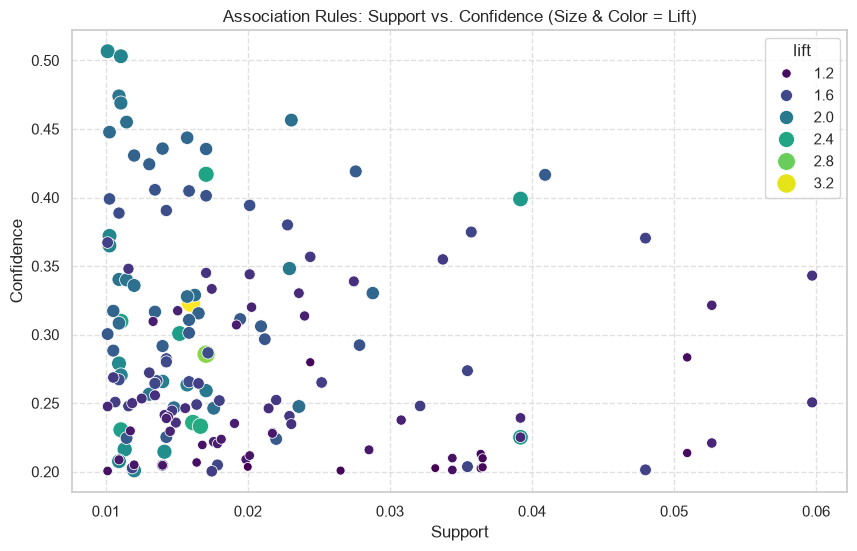

--- TOP 10 STRONGEST PRODUCT ASSOCIATIONS BY LIFT ---
Rule 1: [herb & pepper] ---> [ground beef]
   Support: 0.0160 | Confidence: 0.3235 | Lift: 3.2920

Rule 2: [spaghetti, mineral water] ---> [ground beef]
   Support: 0.0171 | Confidence: 0.2857 | Lift: 2.9079

Rule 3: [tomatoes] ---> [frozen vegetables]
   Support: 0.0161 | Confidence: 0.2359 | Lift: 2.4745

Rule 4: [shrimp] ---> [frozen vegetables]
   Support: 0.0167 | Confidence: 0.2332 | Lift: 2.4466

Rule 5: [milk, mineral water] ---> [frozen vegetables]
   Support: 0.0111 | Confidence: 0.2306 | Lift: 2.4187

Rule 6: [ground beef, mineral water] ---> [spaghetti]
   Support: 0.0171 | Confidence: 0.4169 | Lift: 2.3947

Rule 7: [mineral water, frozen vegetables] ---> [milk]
   Support: 0.0111 | Confidence: 0.3097 | Lift: 2.3900

Rule 8: [milk, mineral water] ---> [ground beef]
   Support: 0.0111 | Confidence: 0.2306 | Lift: 2.3465

Rule 9: [soup] ---> [milk]
   Support: 0.0152 | Confidence: 0.3008 | Lift: 2.3212

Rule 10: [spaghetti

In [8]:
# Step 4.1: Visualize Support vs. Confidence colored by Lift
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=filtered_rules, 
    x='support', 
    y='confidence', 
    size='lift', 
    hue='lift', 
    palette='viridis', 
    sizes=(40, 200)
)
plt.title('Association Rules: Support vs. Confidence (Size & Color = Lift)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Step 4.2: Top 10 Rules by Lift
top_10_lift = filtered_rules.head(10)
print("--- TOP 10 STRONGEST PRODUCT ASSOCIATIONS BY LIFT ---")
for idx, row in top_10_lift.reset_index().iterrows():
    print(f"Rule {idx+1}: [{row['antecedents']}] ---> [{row['consequents']}]")
    print(f"   Support: {row['support']:.4f} | Confidence: {row['confidence']:.4f} | Lift: {row['lift']:.4f}\n")

Products with high Lift (> 2.0) represent strong complementary purchases (e.g., items frequently bought together like spaghetti & ground beef or herb & pepper & ground beef). These items should be placed near each other on shelves or suggested automatically in the digital checkout cart.